In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-approval-classification-data' dataset.
Path to dataset files: /kaggle/input/loan-approval-classification-data


1. person_age: Age of the person
2. person_gender:	Gender of the person
3. person_education:	Highest education level
4. person_income:	Annual income
5. person_emp_exp:	Years of employment experience
6. person_home_ownership:	Home ownership status (e.g., rent, own, mortgage)
7. loan_amnt;	Loan amount requested
8. loan_intent:	Purpose of the loan
9. loan_int_rate:	Loan interest rate
10. loan_percent_income:	Loan amount as a percentage of annual income
11. cb_person_cred_hist_length:	Length of credit history in years
12. credit_score:	Credit score of the person	Integer
13. previous_loan_defaults_on_file:	Indicator of previous loan defaults
14. loan_status: (target variable)	Loan approval status: 1 = approved; 0 = rejected

In [ ]:
df=pd.read_csv('/kaggle/input/loan-approval-classification-data/loan_data.csv')

In [ ]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['person_gender'].value_counts()

,count
person_gender,
male,24841
female,20159


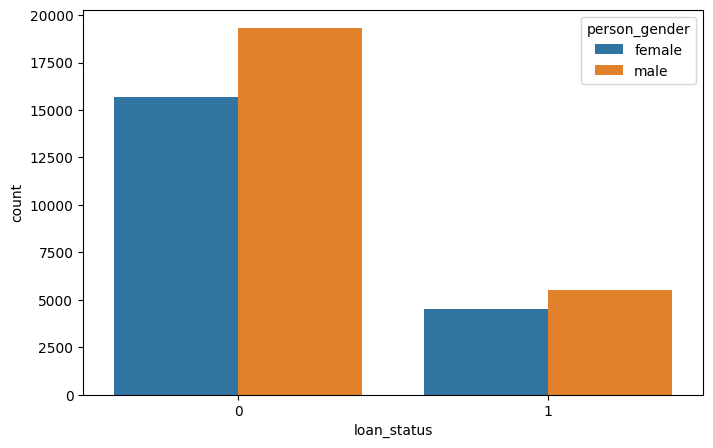

In [ ]:
# gender wise loan approved visulatzation
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='loan_status',hue='person_gender')
plt.show()

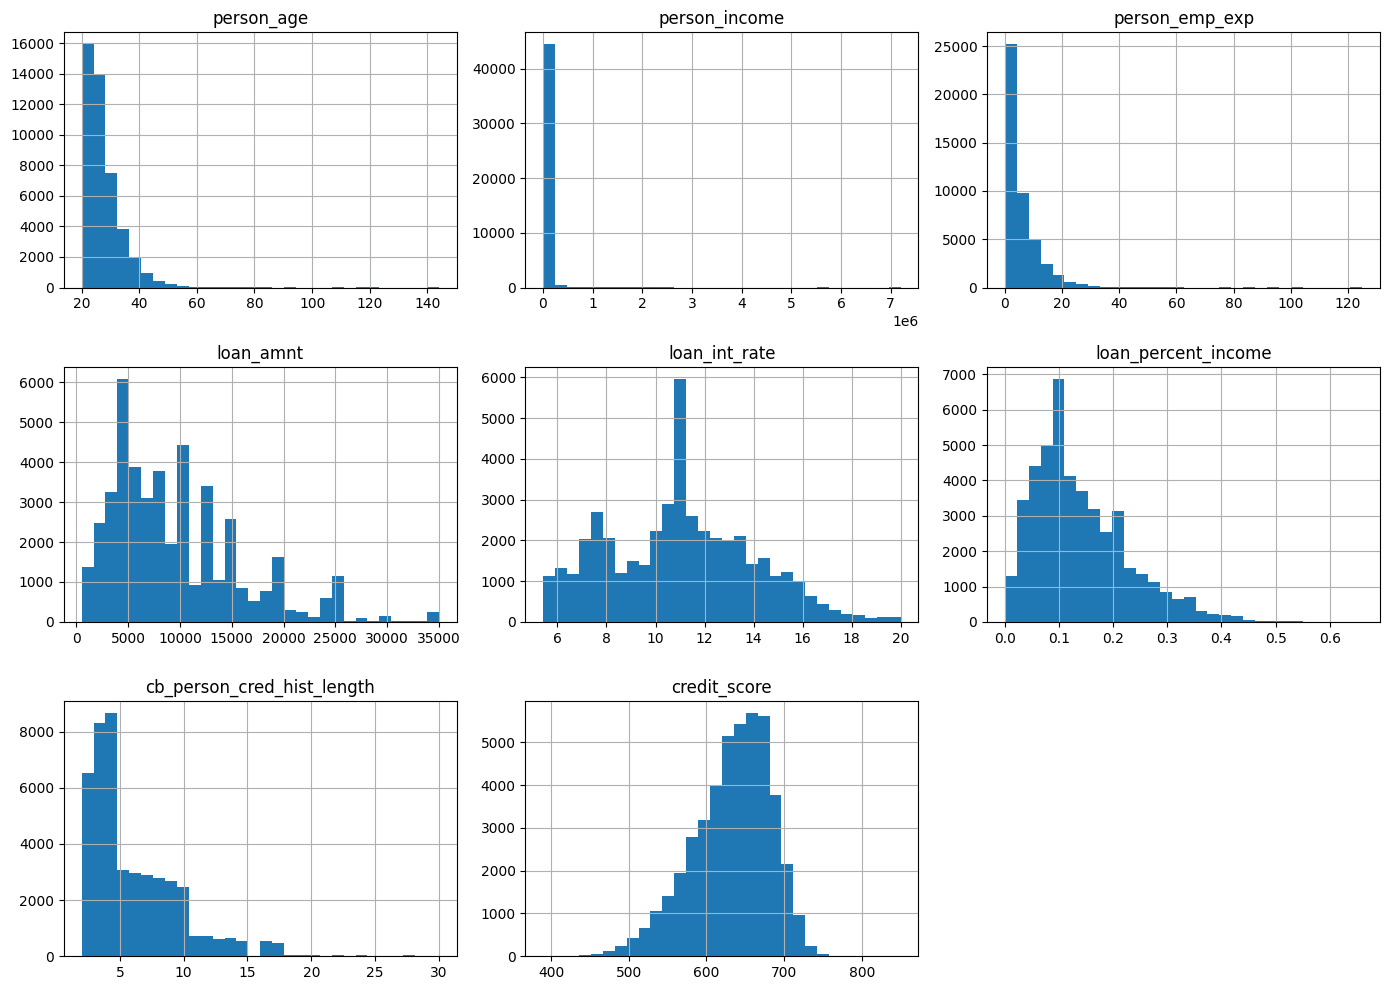

In [ ]:
num_cols = [
    'person_age', 'person_income', 'person_emp_exp',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'credit_score'
]

df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


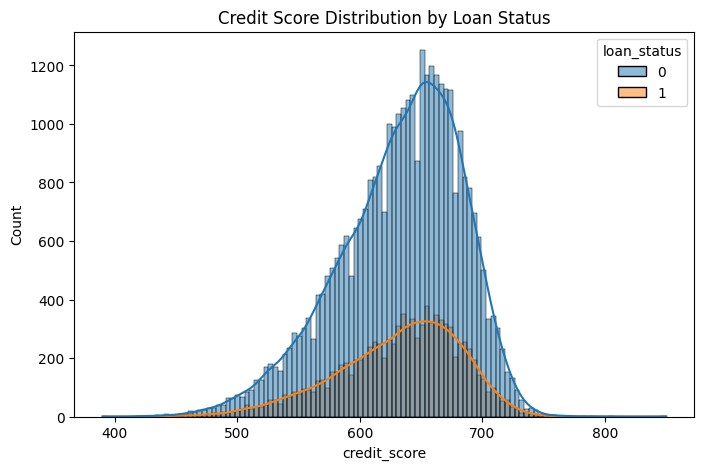

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='credit_score', hue='loan_status', kde=True)
plt.title("Credit Score Distribution by Loan Status")
plt.show()


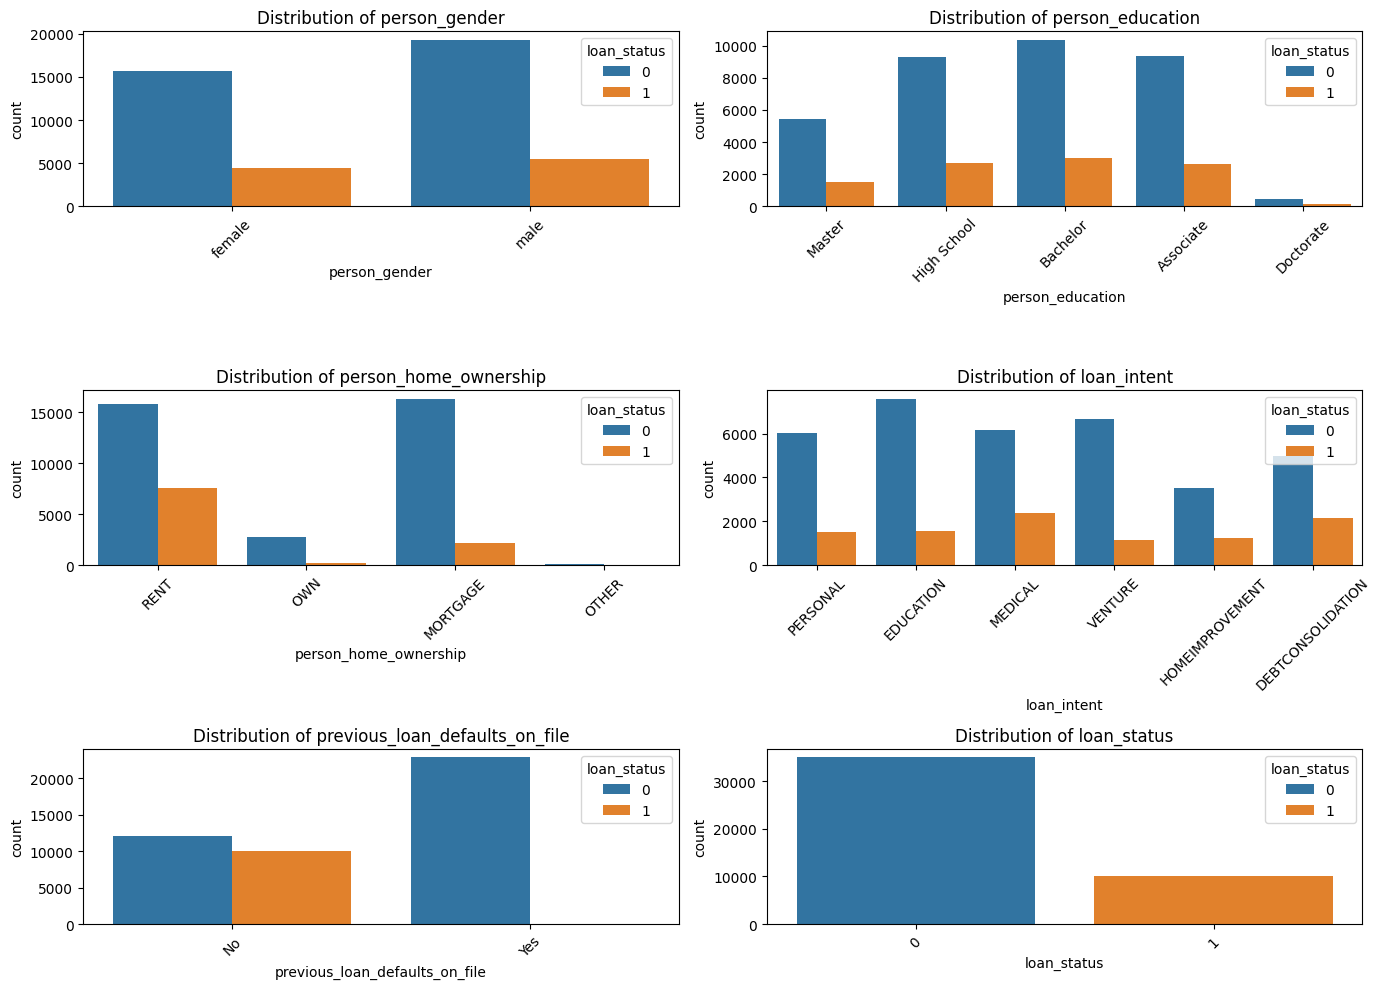

In [ ]:
cat_cols = [
    'person_gender', 'person_education', 'person_home_ownership',
    'loan_intent', 'previous_loan_defaults_on_file', 'loan_status'
]

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col, hue= 'loan_status')
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


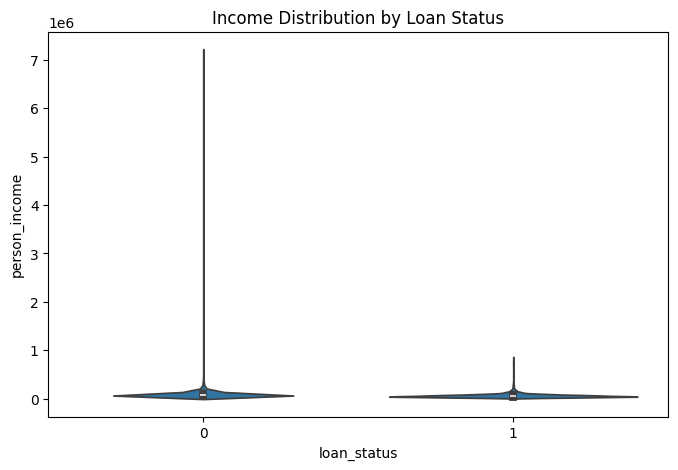

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='loan_status', y='person_income')
plt.title("Income Distribution by Loan Status")
plt.show()

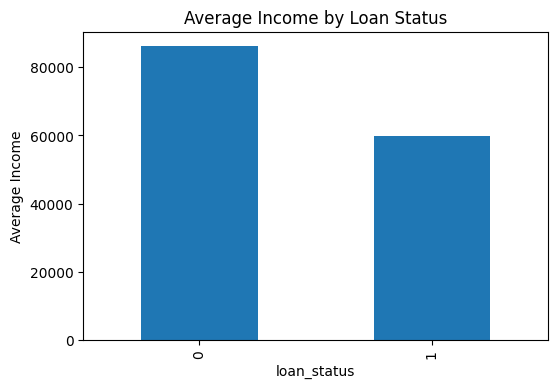

In [ ]:
df.groupby('loan_status')['person_income'].mean().plot(
    kind='bar', figsize=(6,4)
)
plt.title("Average Income by Loan Status")
plt.ylabel("Average Income")
plt.show()


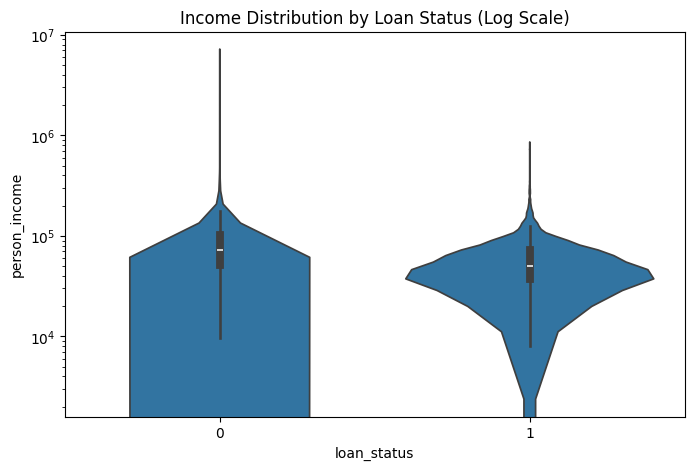

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='loan_status', y='person_income')
plt.yscale('log')
plt.title("Income Distribution by Loan Status (Log Scale)")
plt.show()


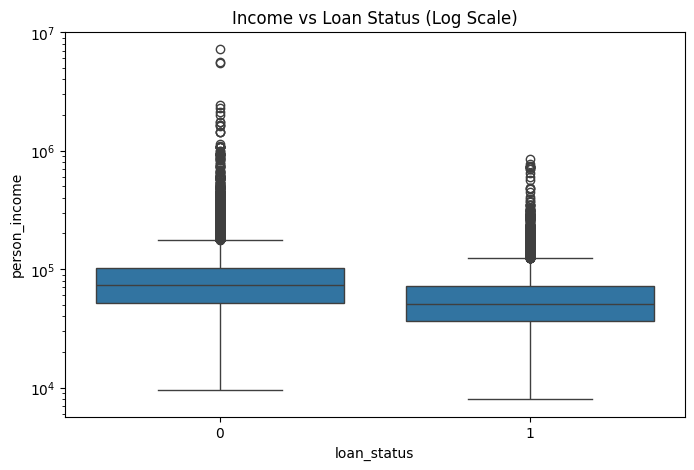

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='loan_status', y='person_income')
plt.yscale('log')
plt.title("Income vs Loan Status (Log Scale)")
plt.show()


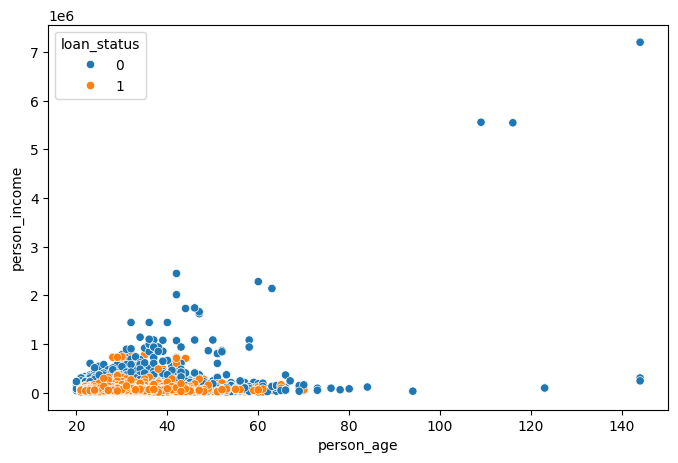

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='person_age', y='person_income', hue='loan_status')
plt.show()

In [ ]:
df=df[df['person_age']<100]

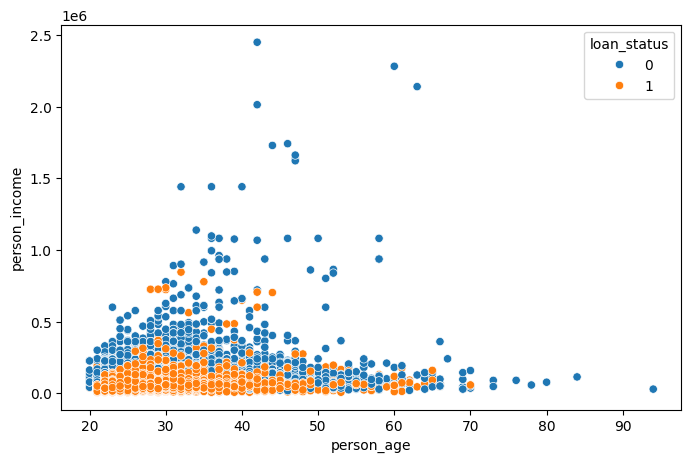

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='person_age', y='person_income', hue='loan_status')
plt.show()

In [ ]:
q1=df['person_income'].quantile(0.25)
q3=df['person_income'].quantile(0.75)

iqr=q3-q1
upper_limit = q3+1.5*iqr
lower_limit = q1-1.5*iqr
df=df[(df['person_income']<upper_limit) & (df['person_income']>lower_limit)]

In [ ]:
upper_limit, lower_limit

(np.float64(168652.5), np.float64(-25679.5))

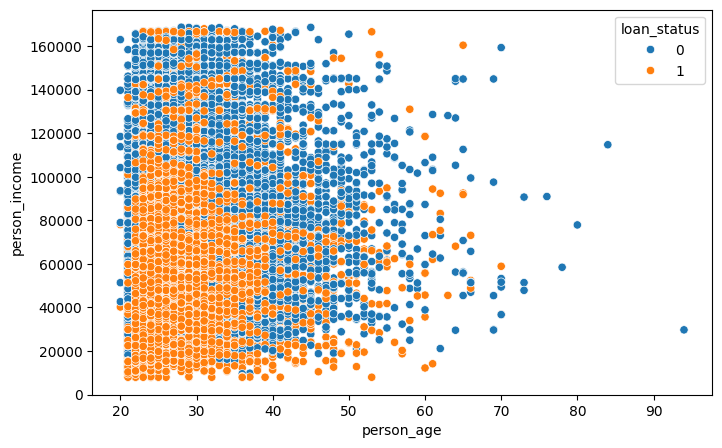

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='person_age', y='person_income', hue='loan_status')
plt.show()

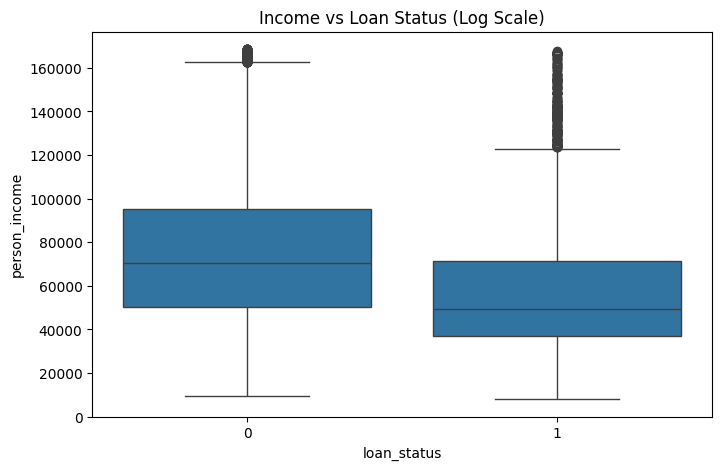

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='loan_status', y='person_income')
# plt.yscale('log')
plt.title("Income vs Loan Status (Log Scale)")
plt.show()

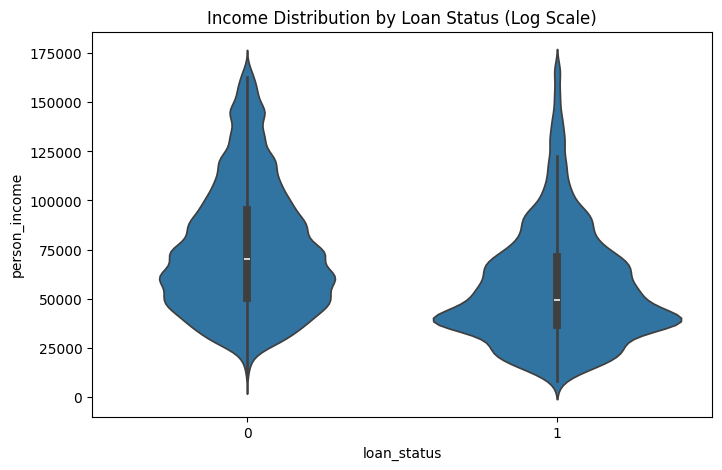

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='loan_status', y='person_income')
# plt.yscale('log')
plt.title("Income Distribution by Loan Status (Log Scale)")
plt.show()

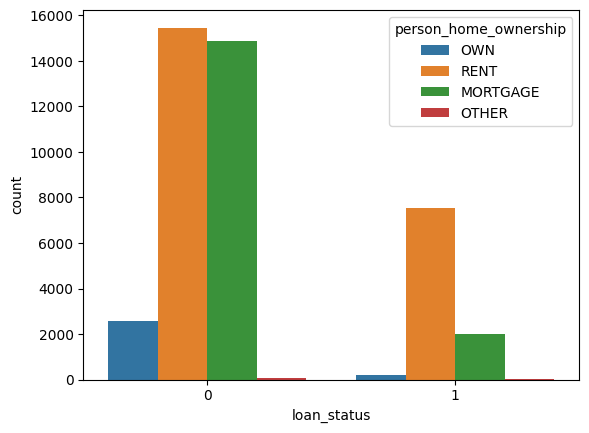

In [ ]:
sns.countplot(data=df, x='loan_status', hue='person_home_ownership')
plt.show()

In [ ]:
num=[]
for i in df.columns:
    if df[i].dtype!='object':
        num.append(i)

In [ ]:
# plt.figure(figsize=(15,10))
# sns.pairplot(df[num], hue='loan_status')
# plt.show()


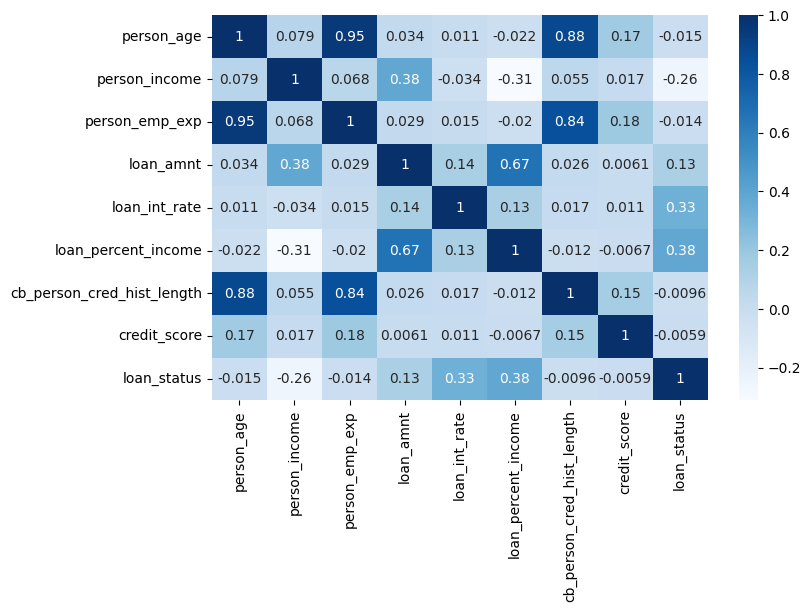

In [ ]:
# heat map
plt.figure(figsize=(8,5))
sns.heatmap(df[num].corr(), annot=True, cmap='Blues')
plt.show()

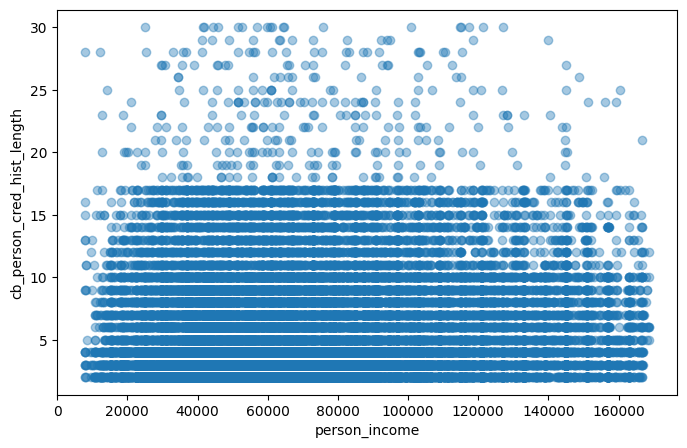

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['person_income'], df['cb_person_cred_hist_length'],alpha=0.4)
plt.xlabel("person_income")
plt.ylabel("cb_person_cred_hist_length")
plt.show()

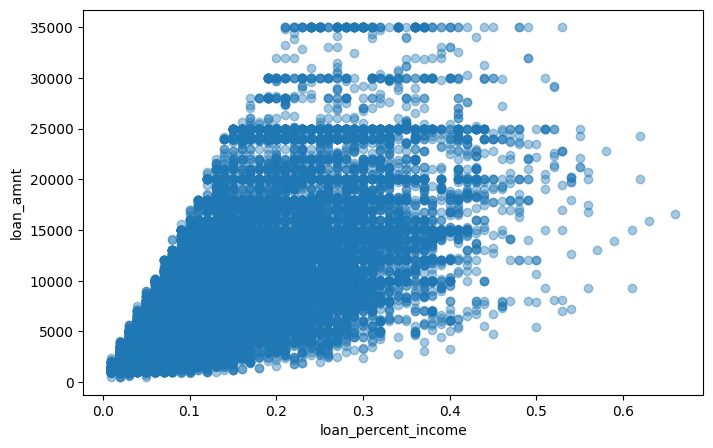

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['loan_percent_income'], df['loan_amnt'],alpha=0.4)
plt.xlabel("loan_percent_income")
plt.ylabel("loan_amnt")
plt.show()

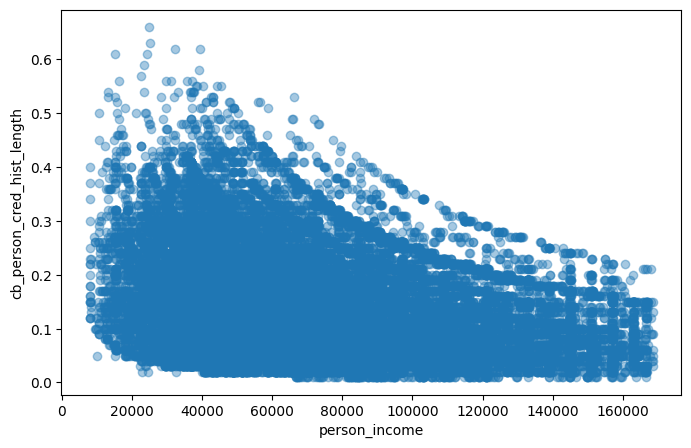

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['person_income'], df['loan_percent_income'],alpha=0.4)
plt.xlabel("person_income")
plt.ylabel("cb_person_cred_hist_length")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
mappings={}
le=LabelEncoder()
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=le.fit_transform(df[i])
    mappings[i]=dict(zip(le.classes_, le.transform(le.classes_)))

In [ ]:
df

In [ ]:
x=df.drop('loan_status', axis=1)
y=df['loan_status']

In [ ]:
# pca
from sklearn.decomposition import PCA

In [ ]:
pca=PCA(n_components=10)
x_pca=pca.fit_transform(x)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(x_pca)

In [ ]:
x_scaled

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)*100
print("Accuracy:", acc_lr)

In [ ]:
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

In [ ]:
print(roc_auc_score(y_test, y_pred_lr))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)*100
print("Accuracy:", acc_rf)

In [ ]:
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

In [ ]:
print(roc_auc_score(y_test, y_pred_rf))

In [ ]:
from sklearn.svm import SVC
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)*100
print("Accuracy:", acc_svm)
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

In [ ]:
print(roc_auc_score(y_test, y_pred_svm))

In [ ]:
# xgboost
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)*100
print("Accuracy:", acc_xgb)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

In [ ]:
print(roc_auc_score(y_test, y_pred_xgb))

In [ ]:
# visuliaze roc auc
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
# light
from lightgbm import LGBMClassifier
lgb = LGBMClassifier()
y_pred_lgb = lgb.fit(X_train, y_train).predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)*100
print("Accuracy:", acc_lr)
print(confusion_matrix(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))

In [ ]:
print(roc_auc_score(y_test, y_pred_lgb))

Based on the evaluation metrics, here is the conclusion:

1. Logistic Regression:

Accuracy: 83.51%

ROC AUC Score: 0.6978

The model shows reasonable overall accuracy but struggles with recall for the positive class (loan approved), indicating it misses a significant portion of actual approved loans.

2. Support Vector Machine (SVM):

Accuracy: 83.42%

ROC AUC Score: 0.6809

Similar to Logistic Regression, SVM also achieves comparable accuracy but has a low recall for the positive class.

3. Random Forest Classifier:

Accuracy: 90.30%

ROC AUC Score: 0.8164

Random Forest significantly outperforms Logistic Regression and SVM in terms of accuracy and ROC AUC score, demonstrating a much better balance between precision and recall for both classes.

4. XGBoost Classifier:

Accuracy: 90.81%

ROC AUC Score: **0.8350**

XGBoost further improves upon Random Forest, achieving the highest accuracy and ROC AUC score among all models tested. It shows strong performance in correctly identifying both approved and rejected loans.

5. LightGBM Classifier:

Accuracy: 90.74%

ROC AUC Score: 0.8286

LightGBM also performs very well, with accuracy and ROC AUC score close to XGBoost, making it another strong contender for this classification task.

Conclusion:

Both XGBoost and LightGBM models demonstrated superior performance for this loan approval classification task, with XGBoost slightly outperforming LightGBM in terms of accuracy (90.81% vs 90.74%) and ROC AUC score (0.8350 vs 0.8286). These tree-based ensemble methods are more effective at capturing the complex relationships within the data compared to the linear models (Logistic Regression and SVM). The high ROC AUC scores for XGBoost and LightGBM indicate their ability to distinguish between the two classes effectively, which is crucial for a balanced and robust loan approval prediction system.